# Production Stacked Ensemble and Validation-Tuned Decision Policy

## Objective

This notebook explains the current production `stacked_ensemble` model and the validation-tuned H/D/A decision policy.

The probability model is implemented in `scripts/models/epl_production_model.py`. The script trains calibrated logistic regression, random forest, and LightGBM models, stacks their probabilities with bookmaker probabilities, and saves final predictions. The decision policy is tuned only on chronological validation predictions, then evaluated once on the untouched `2025_2026` test season.

## 1. Model Summary

The `stacked_ensemble` combines four probability sources:

- Logistic regression probabilities
- Random forest probabilities
- LightGBM probabilities
- Bookmaker normalized implied probabilities

A logistic regression meta-model learns how to combine those inputs into final probabilities for home win, draw, and away win.

The final class label can be chosen in two ways:

- `model_prediction`: simple argmax of the stacked probabilities
- `policy_prediction`: validation-tuned decision policy applied to the same probabilities

The policy can improve label accuracy or class balance, but it does not change log loss or RPS because the probabilities are unchanged.

## 2. Load Outputs

In [50]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

final_metrics = pd.read_csv(PROCESSED_DIR / "epl_model_final_metrics.csv")
validation_metrics = pd.read_csv(PROCESSED_DIR / "epl_model_validation_metrics.csv")
validation_predictions = pd.read_csv(PROCESSED_DIR / "epl_model_validation_predictions.csv")
decision_policy_results = pd.read_csv(PROCESSED_DIR / "epl_model_decision_policy_results.csv")
predictions = pd.read_csv(PROCESSED_DIR / "epl_model_predictions.csv")

print(f"Final metrics shape: {final_metrics.shape}")
print(f"Validation metrics shape: {validation_metrics.shape}")
print(f"Validation predictions shape: {validation_predictions.shape}")
print(f"Decision policy results shape: {decision_policy_results.shape}")
print(f"Final predictions shape: {predictions.shape}")

Final metrics shape: (6, 14)
Validation metrics shape: (13, 8)
Validation predictions shape: (1520, 17)
Decision policy results shape: (3834, 19)
Final predictions shape: (380, 19)


## 3. Validation and Test Separation

Decision-policy tuning must not use `2025_2026`. The validation prediction file should contain only `2021_2022` through `2024_2025`, while the final prediction file should contain only `2025_2026`.

In [51]:
checks = {
    "validation_seasons": sorted(validation_predictions["Season"].unique()),
    "test_seasons": sorted(predictions["Season"].unique()),
    "validation_duplicate_match_ids": int(validation_predictions["MatchID"].duplicated().sum()),
    "test_duplicate_match_ids": int(predictions["MatchID"].duplicated().sum()),
    "validation_prob_sum_max_error": float(abs(validation_predictions[["model_prob_home", "model_prob_draw", "model_prob_away"]].sum(axis=1) - 1).max()),
    "test_prob_sum_max_error": float(abs(predictions[["model_prob_home", "model_prob_draw", "model_prob_away"]].sum(axis=1) - 1).max()),
}
checks

{'validation_seasons': ['2021_2022', '2022_2023', '2023_2024', '2024_2025'],
 'test_seasons': ['2025_2026'],
 'validation_duplicate_match_ids': 0,
 'test_duplicate_match_ids': 0,
 'validation_prob_sum_max_error': 3.3306690738754696e-16,
 'test_prob_sum_max_error': 3.3306690738754696e-16}

### Findings

The decision policy is selected from validation seasons only. The final `2025_2026` rows are used only after the policy is fixed.

## 4. Base Probability Model Performance

These metrics evaluate the underlying probability models. For log loss and RPS, lower is better. For accuracy and macro F1, higher is better.

In [52]:
metric_cols = ["model", "fold", "accuracy", "macro_f1", "draw_recall", "log_loss", "rps", "avg_confidence"]
final_metrics[metric_cols].sort_values("log_loss").round(4)

,model,fold,accuracy,macro_f1,draw_recall,log_loss,rps,avg_confidence
4,bookmaker_baseline,2025_2026,0.4947,0.3714,0.0000,1.0118,0.2045,0.5174
3,stacked_ensemble,2025_2026,0.4842,0.3714,0.0096,1.0219,0.2079,0.5074
5,stacked_ensemble_policy,2025_2026,0.4711,0.3951,0.0673,1.0219,0.2079,0.5074
1,random_forest,2025_2026,0.4684,0.3602,0.0000,1.0339,0.2114,0.5099
0,logistic,2025_2026,0.4763,0.3661,0.0000,1.0469,0.2162,0.4990
2,lightgbm,2025_2026,0.4500,0.3576,0.0192,1.0558,0.2181,0.5049


### Findings

The bookmaker baseline remains the strongest probability source on the untouched `2025_2026` test season. Among trained ML models, the stacked ensemble is the best probability model. The validation-tuned policy uses the stacked ensemble probabilities, so its log loss and RPS are identical to the stacked ensemble.

## 5. Chronological Validation Metrics

The stacked model is built from chronological validation folds:

- Train through `2020_2021`, validate `2021_2022`
- Train through `2021_2022`, validate `2022_2023`
- Train through `2022_2023`, validate `2023_2024`
- Train through `2023_2024`, validate `2024_2025`

In [53]:
validation_metrics[metric_cols].round(4)

,model,fold,accuracy,macro_f1,draw_recall,log_loss,rps,avg_confidence
0,logistic_fold_2021_2022,2021_2022,0.5237,0.3951,0.0000,1.0141,0.2134,0.4685
1,random_forest_fold_2021_2022,2021_2022,0.5474,0.4129,0.0000,0.9725,0.2003,0.5249
2,lightgbm_fold_2021_2022,2021_2022,0.5421,0.4105,0.0000,0.9883,0.2038,0.5097
3,logistic_fold_2022_2023,2022_2023,0.5211,0.3826,0.0000,1.0017,0.2099,0.4947
4,random_forest_fold_2022_2023,2022_2023,0.5421,0.4154,0.0345,0.9673,0.1979,0.5388
5,lightgbm_fold_2022_2023,2022_2023,0.5263,0.4110,0.0575,0.9629,0.1988,0.5281
6,logistic_fold_2023_2024,2023_2024,0.5553,0.3994,0.0000,0.9460,0.1946,0.5320
7,random_forest_fold_2023_2024,2023_2024,0.5816,0.4239,0.0000,0.9208,0.1873,0.5537
8,lightgbm_fold_2023_2024,2023_2024,0.5816,0.4290,0.0122,0.9395,0.1925,0.5479
9,logistic_fold_2024_2025,2024_2025,0.5289,0.3942,0.0000,0.9899,0.2025,0.5540


## 6. Validation-Tuned Decision Policy Search

The production script now searches decision policies on validation predictions only.

Two policy families are considered:

- `threshold`: class-specific minimum probability thresholds, with fallback to argmax
- `bias`: class-specific probability offsets before argmax, with home anchored at zero for identifiability

The selected policy is ranked by validation accuracy first, macro F1 second, and lower policy complexity third.

In [54]:
policy_cols = [
    "selected", "policy_type", "policy_name", "accuracy", "macro_f1",
    "draw_precision", "draw_recall", "draw_f1", "home_picks", "draw_picks", "away_picks",
    "threshold_home", "threshold_draw", "threshold_away", "bias_home", "bias_draw", "bias_away", "complexity"
]
decision_policy_results[policy_cols].head(15).round(4)

,selected,policy_type,policy_name,accuracy,macro_f1,draw_precision,draw_recall,draw_f1,home_picks,draw_picks,away_picks,threshold_home,threshold_draw,threshold_away,bias_home,bias_draw,bias_away,complexity
0,True,bias,bias_h0.000_d0.035_a0.010,0.5743,0.4600,0.4118,0.0600,0.1047,884,51,585,NaN,NaN,NaN,0.0,0.035,0.010,0.045
1,False,bias,bias_h0.000_d0.035_a0.015,0.5743,0.4590,0.4082,0.0571,0.1003,879,49,592,NaN,NaN,NaN,0.0,0.035,0.015,0.050
2,False,bias,bias_h0.000_d0.045_a0.020,0.5730,0.4666,0.3768,0.0743,0.1241,859,69,592,NaN,NaN,NaN,0.0,0.045,0.020,0.065
3,False,bias,bias_h0.000_d0.040_a0.015,0.5730,0.4612,0.3793,0.0629,0.1078,872,58,590,NaN,NaN,NaN,0.0,0.040,0.015,0.055
4,False,bias,bias_h0.000_d0.040_a0.020,0.5724,0.4592,0.3889,0.0600,0.1040,870,54,596,NaN,NaN,NaN,0.0,0.040,0.020,0.060
5,False,bias,bias_h0.000_d0.035_a0.020,0.5724,0.4535,0.4146,0.0486,0.0870,875,41,604,NaN,NaN,NaN,0.0,0.035,0.020,0.055
6,False,bias,bias_h0.000_d0.030_a0.010,0.5724,0.4530,0.4146,0.0486,0.0870,892,41,587,NaN,NaN,NaN,0.0,0.030,0.010,0.040
7,False,bias,bias_h0.000_d0.030_a0.015,0.5724,0.4489,0.4242,0.0400,0.0731,887,33,600,NaN,NaN,NaN,0.0,0.030,0.015,0.045
8,False,bias,bias_h0.000_d0.010_a-0.015,0.5724,0.4430,0.4583,0.0314,0.0588,936,24,560,NaN,NaN,NaN,0.0,0.010,-0.015,0.025
9,False,threshold,threshold_h0.320_d0.360_a0.360,0.5724,0.4266,0.5000,0.0029,0.0057,963,2,555,0.32,0.36,0.36,0.0,0.000,0.000,1.040


### Selected Policy

The selected policy is chosen from validation folds only. It is then applied once to the `2025_2026` test predictions.

In [55]:
selected_policy = decision_policy_results[decision_policy_results["selected"]].iloc[0]
selected_policy[policy_cols].to_frame("value")

,value
selected,True
policy_type,bias
policy_name,bias_h0.000_d0.035_a0.010
accuracy,0.574342
macro_f1,0.460015
draw_precision,0.411765
draw_recall,0.06
draw_f1,0.104738
home_picks,884
draw_picks,51


### Findings

The validation search selected a small `bias` policy. It slightly boosts draw and away probabilities relative to home before choosing the final label. On validation data, this improved accuracy compared with the plain argmax policy.

## 7. Final Test: Argmax vs Validation-Tuned Policy

This is the most important comparison for the decision policy. The policy was selected before looking at `2025_2026`, so this table shows whether the validation-tuned rule generalized to the final test season.

In [56]:
def label_metrics(y_true, y_pred, name):
    return {
        "decision_rule": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, labels=["H", "D", "A"], average="macro", zero_division=0),
        "home_picks": int((pd.Series(y_pred) == "H").sum()),
        "draw_picks": int((pd.Series(y_pred) == "D").sum()),
        "away_picks": int((pd.Series(y_pred) == "A").sum()),
    }

y_true = predictions["FTR"]
comparison = pd.DataFrame([
    label_metrics(y_true, predictions["model_prediction"], "stacked_argmax"),
    label_metrics(y_true, predictions["policy_prediction"], "validation_tuned_policy"),
    label_metrics(y_true, predictions["bookmaker_implied_favorite"], "bookmaker_favorite"),
])
comparison.round(4)

,decision_rule,accuracy,macro_f1,home_picks,draw_picks,away_picks
0,stacked_argmax,0.4842,0.3714,215,2,163
1,validation_tuned_policy,0.4711,0.3951,194,30,156
2,bookmaker_favorite,0.4947,0.3714,237,0,143


### Findings

The validation-tuned policy did not improve final `2025_2026` accuracy. It improved draw recall and macro F1 relative to the original stacked argmax, but it made too many incorrect label changes to improve accuracy.

This is the right result to document: the policy was tuned on validation folds, tested once on `2025_2026`, and did not generalize as an accuracy improvement.

## 8. Confusion Matrix: Current Argmax

In [57]:
labels = ["H", "D", "A"]
argmax_cm = confusion_matrix(predictions["FTR"], predictions["model_prediction"], labels=labels)
argmax_cm_df = pd.DataFrame(argmax_cm, index=[f"actual_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])
argmax_cm_df

,pred_H,pred_D,pred_A
actual_H,118,0,44
actual_D,49,1,54
actual_A,48,1,65


## 9. Confusion Matrix: Validation-Tuned Policy

In [58]:
policy_cm = confusion_matrix(predictions["FTR"], predictions["policy_prediction"], labels=labels)
policy_cm_df = pd.DataFrame(policy_cm, index=[f"actual_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])
policy_cm_df

,pred_H,pred_D,pred_A
actual_H,108,13,41
actual_D,46,7,51
actual_A,40,10,64


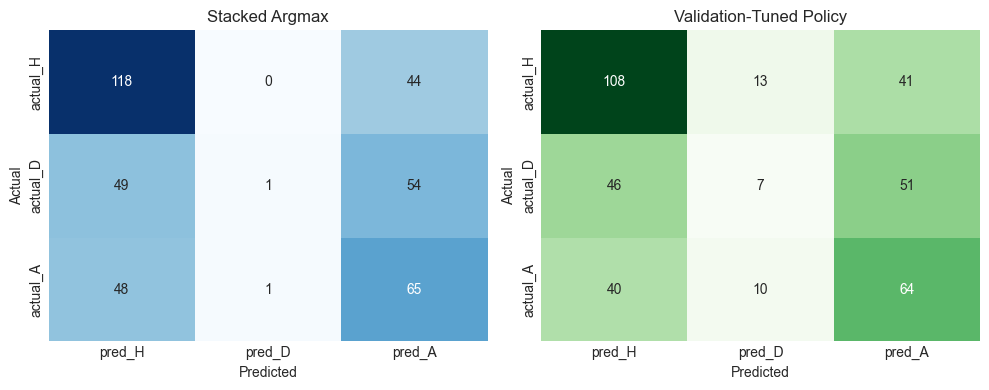

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(argmax_cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Stacked Argmax")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(policy_cm_df, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Validation-Tuned Policy")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Findings

The policy predicts more draws than argmax, but many of those extra draw predictions are false positives. That explains why draw recall improves while overall accuracy falls.

## 10. Classification Reports

In [60]:
print("Stacked argmax")
print(classification_report(
    predictions["FTR"],
    predictions["model_prediction"],
    labels=labels,
    target_names=["home_win", "draw", "away_win"],
    zero_division=0,
))

print("Validation-tuned policy")
print(classification_report(
    predictions["FTR"],
    predictions["policy_prediction"],
    labels=labels,
    target_names=["home_win", "draw", "away_win"],
    zero_division=0,
))

Stacked argmax
              precision    recall  f1-score   support

    home_win       0.55      0.73      0.63       162
        draw       0.50      0.01      0.02       104
    away_win       0.40      0.57      0.47       114

    accuracy                           0.48       380
   macro avg       0.48      0.44      0.37       380
weighted avg       0.49      0.48      0.41       380

Validation-tuned policy
              precision    recall  f1-score   support

    home_win       0.56      0.67      0.61       162
        draw       0.23      0.07      0.10       104
    away_win       0.41      0.56      0.47       114

    accuracy                           0.47       380
   macro avg       0.40      0.43      0.40       380
weighted avg       0.42      0.47      0.43       380



## 11. Model-vs-Market Edges

The final predictions still include model-vs-bookmaker probability edges. Since the bookmaker baseline remains stronger on log loss, these edge columns are useful for later analysis of where the model disagrees with the market.

In [61]:
edge_cols = ["edge_home", "edge_draw", "edge_away"]
predictions[edge_cols].describe().round(4)

,edge_home,edge_draw,edge_away
count,380.0000,380.0000,380.0000
mean,-0.0345,0.0345,0.0000
std,0.0292,0.0157,0.0253
min,-0.1070,-0.0030,-0.0666
25%,-0.0559,0.0237,-0.0188
50%,-0.0368,0.0343,-0.0005
75%,-0.0149,0.0449,0.0189
max,0.0368,0.0763,0.0714


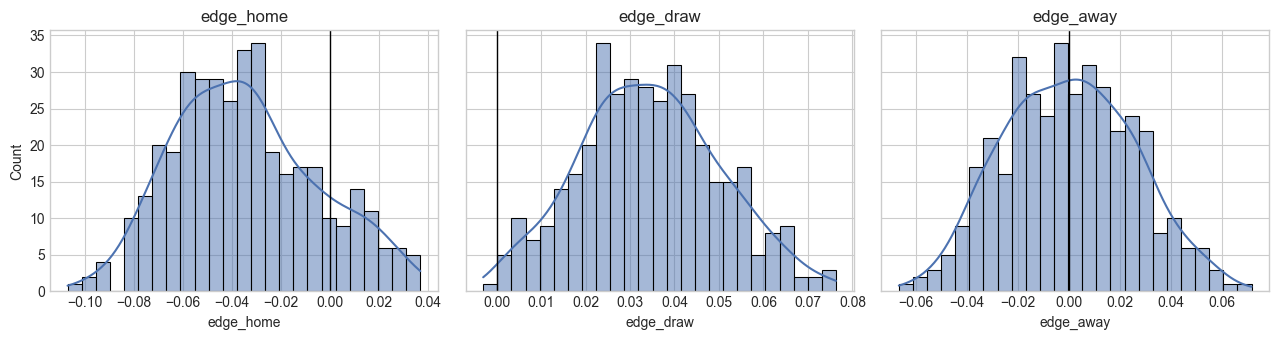

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, col in zip(axes, edge_cols):
    sns.histplot(predictions[col], bins=25, kde=True, ax=ax)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 12. Conclusion

The best trained probability model is still the `stacked_ensemble`, and the best overall probability source is still the bookmaker baseline.

The validation-tuned decision policy is methodologically better than tuning thresholds on the test set, but it did not improve final test accuracy. The current production class label should therefore remain `model_prediction` unless the goal shifts from highest accuracy to better draw coverage.

The next useful modeling direction is probability calibration and model-vs-market edge analysis, because decision policies can only change labels. They cannot improve log loss without changing the underlying probabilities.